**install packages**

In [1]:
!pip install ultralytics pyyaml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.7 MB/s eta 0:00:00


**imports**

In [2]:
from ultralytics import YOLO
import os
import zipfile
import yaml

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


**upload dataset zip**

In [3]:
from google.colab import files
uploaded = files.upload()

Saving ppe-detection-v1.v1i.yolov8.zip to ppe-detection-v1.v1i.yolov8.zip


**unzip dataset**

In [4]:
zip_name = list(uploaded.keys())[0]
extract_path = "/content/ppe_dataset"

with zipfile.ZipFile(zip_name, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted to:", extract_path)

Dataset extracted to: /content/ppe_dataset


**folder structure check**

In [5]:
for root, dirs, files in os.walk("/content/ppe_dataset"):
    print(root)
    for f in files[:5]:
        print("   ", f)

/content/ppe_dataset
    data.yaml
    README.roboflow.txt
    README.dataset.txt
/content/ppe_dataset/valid
/content/ppe_dataset/valid/images
    15_jpeg.rf.2fe987eb4c512abfa163cb00d1cca3da.jpg
    Screenshot_2024-10-04-15-40-31-55_254de13a4bc8758c9908fff1f73e3725_jpg.rf.2be8edfd818826161493ac3d65ea3a44.jpg
    Screenshot_2024-10-04-15-40-25-74_254de13a4bc8758c9908fff1f73e3725_jpg.rf.a5461adff51166e403d452cde4187869.jpg
    7_jpg.rf.bd2e4fc80c05f798503921c1f121ba40.jpg
    14_jpeg.rf.2271a8fcc5b8c1fe7d6dfbf85e4eecb4.jpg
/content/ppe_dataset/valid/labels
    Screenshot_2024-10-04-15-40-24-64_254de13a4bc8758c9908fff1f73e3725_jpg.rf.6521e4e182c43ea8326688e41ae0e880.txt
    Screenshot_2024-10-04-15-40-25-74_254de13a4bc8758c9908fff1f73e3725_jpg.rf.a5461adff51166e403d452cde4187869.txt
    17_jpeg.rf.a7e5455aef85d874884d3fa56c3a115f.txt
    Screenshot_2024-10-04-15-40-32-69_254de13a4bc8758c9908fff1f73e3725_jpg.rf.25f3d42ec9385d5f1692c73e34863a94.txt
    38_jpg.rf.4e2bb9c0ab8fbb04a82c968fd207

**data.yaml verify/fix**

In [6]:
yaml_path = None

for root, dirs, files in os.walk("/content/ppe_dataset"):
    if "data.yaml" in files:
        yaml_path = os.path.join(root, "data.yaml")
        break

print("Found data.yaml:", yaml_path)

with open(yaml_path, "r") as f:
    data = yaml.safe_load(f)

print("Original YAML:")
print(data)

Found data.yaml: /content/ppe_dataset/data.yaml
Original YAML:
{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 6, 'names': ['fire', 'glasses', 'helmet', 'overall', 'person', 'smoke'], 'roboflow': {'workspace': 'zaimes-workspace', 'project': 'ppe-detection-v1-6ntwz', 'version': 1, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/zaimes-workspace/ppe-detection-v1-6ntwz/dataset/1'}}


**overwrite clean data.yaml**

In [7]:
dataset_root = os.path.dirname(yaml_path)

yaml_text = """train: train/images
val: valid/images

nc: 6
names:
  0: fire
  1: glasses
  2: helmet
  3: overall
  4: person
  5: smoke
"""

with open(os.path.join(dataset_root, "data.yaml"), "w") as f:
    f.write(yaml_text)

print("Clean data.yaml written at:", os.path.join(dataset_root, "data.yaml"))

Clean data.yaml written at: /content/ppe_dataset/data.yaml


**start training**

In [8]:
model = YOLO("yolov8n.pt")

model.train(
    data=os.path.join(dataset_root, "data.yaml"),
    epochs=70,
    imgsz=640,
    batch=16,
    project="/content/runs",
    name="ppe_hazard_model",
    patience=20
)

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/ppe_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=70, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=ppe_hazard_model, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=20, 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7abe4d0b3e00>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
     

**best model download**

In [10]:
from google.colab import files
files.download("/content/runs/ppe_hazard_model/weights/best.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**metrics check**

In [11]:
results = model.val(data=os.path.join(dataset_root, "data.yaml"))
print(results)

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 945.3±375.6 MB/s, size: 52.9 KB)
val: Scanning /content/ppe_dataset/valid/labels.cache... 75 images, 37 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 75/75 12.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.1s/it 5.5s
                   all         75        646      0.729      0.533        0.6      0.389
                  fire          7         19      0.784      0.684      0.737       0.55
               glasses         27        172       0.95      0.401      0.646      0.333
                helmet         34        238      0.848      0.654      0.734      0.557
               overall         22         64      0.535      0.438      0.435      0.313
                person         26        143      


0: 640x640 1 glasses, 1 helmet, 1 overall, 1 person, 5.3ms
1: 640x640 6 glassess, 22 helmets, 12 overalls, 20 persons, 5.3ms
2: 640x640 1 smoke, 5.3ms
3: 640x640 2 fires, 1 helmet, 1 overall, 1 person, 5.3ms
4: 640x640 (no detections), 5.3ms
Speed: 2.2ms preprocess, 5.3ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


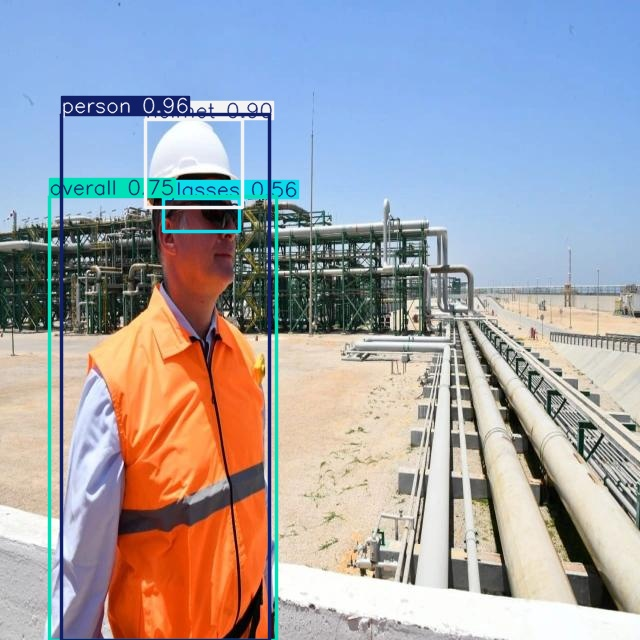

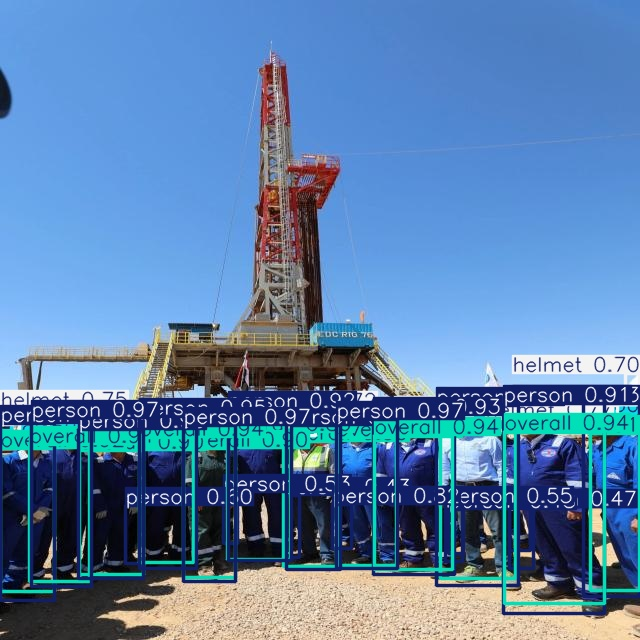

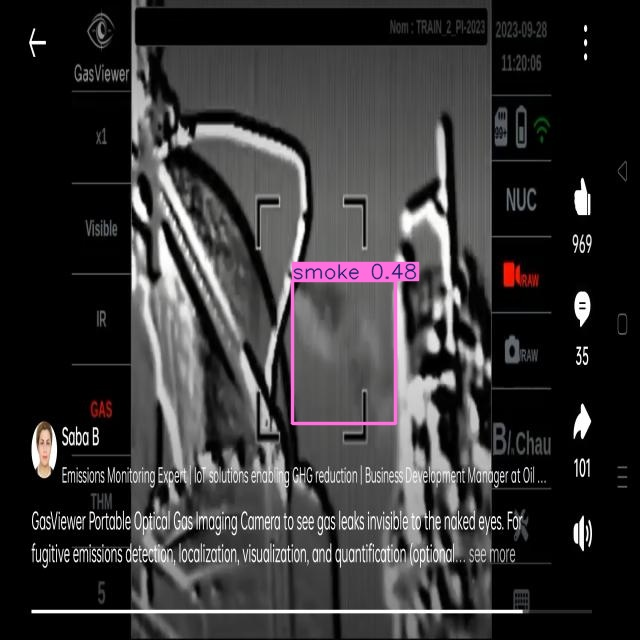

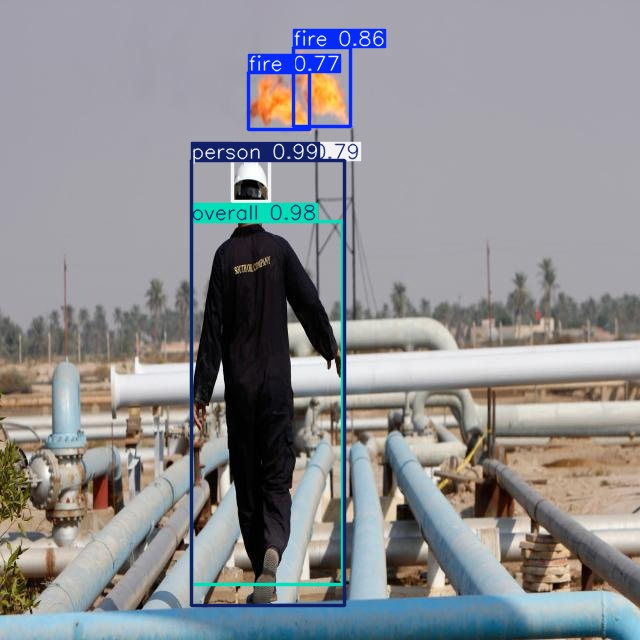

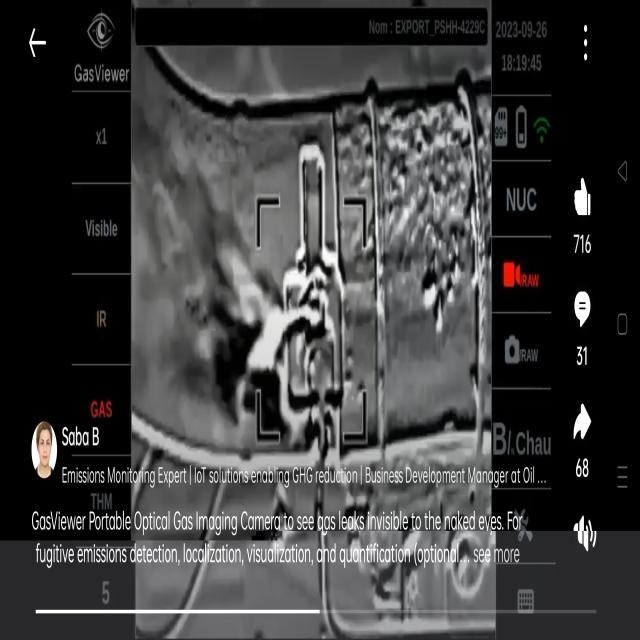

In [20]:
import glob
import random
from IPython.display import Image, display

# Correct path
image_paths = glob.glob("/content/ppe_dataset/train/images/*")

# Random 5 images
sample_images = random.sample(image_paths, 5)

# Run inference
results = model.predict(
    source=sample_images,
    save=True,
    conf=0.4
)

# Predictions folder
pred_dir = "/content/runs/detect/predict"

# Get result images
pred_files = sorted(glob.glob(pred_dir + "/*"))

# Display results
for f in pred_files[:5]:
    display(Image(filename=f))